### Réponse aux questions - Optimisation d'un cycle de réfrigération au CO2

### Q1.1 : En utilisant une méthode itérative, déterminez la température de condensation ($T_{cond}$) (et la pression de saturation associée $P_{3s}$) permettant de respecter le pincement et l'échauffement de l'air. Pour commencer, écrire un bilan de puissance qui inclurait $T_{cond}$.


$c_{p, air} (T_{Ap} - T_{A1}) = \Delta h_{f4 \to f3 sl} + \Delta h_{f3 sl \to f3 sv}$

$c_{p, air} (T_{Ap} - T_{A1}) = l_{vaporisation, CO_{2}}(T_{cond}) - c_{p, CO_{2}, liq} (T_{f4s} - T_{cond})$

Or on a que $T_{Ap} = T_{cond} - 5$ et $T_{A1} = T_{amb}$

On obtient ainsi $T_{cond} = T_{amb} + 5 + \frac{l_{vaporisation, CO_{2}}(T_{cond}) - c_{p, CO_{2}, liq} (T_{f4s} - T_{cond})}{c_{p, air}}$

On va poser $T_0 = 25°C$, soit la température si $Ap=A_2$, et on va itérer en posant à chaque itération :

$T_{k+1} = T_{amb} + 5 + \frac{l_{vaporisation, CO_{2}}(T_{k}) - c_{p, CO_{2}, liq}(T_{k}) (T_{f4s} - T_{cond})}{c_{p, air}(T_{k})}$

Cela va converger vers $T_{cond}$.

On obtient grâce à Coolprop : $T_{cond} = 295 K = 22°C$ et $P_{3s} = 5958210 Pa \approx 59,6$ $bar$

### Q1.2 : Calculez le COP (Coefficient de Performance) du cycle pour ces conditions et tracez le diagramme T-s en y affichant le profil de température de l’air.

On a le COP qui est : $\eta = \frac{q_f}{w}$

On utilise Q1.1 pour trouver $T_{cond}$ et $P_3$.

La clé est d'utiliser CoolProp sachant qu'à chaque point on a besoin de données parmi h, s, P, T pour obtenir les autres (NB : pour un gaz parfait cela ne fonctionne pas avec (h,T) car les deux grandeurs sont liées).

Pour calculer $q_f = h_1 - h_5$, on a besoin de $h_1$ et $h_5$. On trouve $P_{5sv}$ grâce à CoolProp et on utilise le fait que la perte de charges est négligée dans les échangeurs pour en déduire $P_1$. On obtient $h_1$ et $h_4$ grâce à CoolProp et comme la détente est isenthalpique, on : $h_5 = h_4$. On a alors $q_f$.

Pour $w$, on trouve $s_1$ via CoolProp et on utilise l'absence de perte de charges dans le refroidisseur pour affirmer que $P_2 = P_3$. On suppose la compression isentropique, donc $s_{2is} = s_1$ et on trouve ainsi $h_{2is}$ avec CoolProp. On en déduit $w_{is}$ puis $w$ grâce au rapport isentropique obtenu via $P_1$ et $P_2$.

On trouve alors $\eta=4.38$.

Pour effectuer le tracé du diagramme T-s, on doit obtenir la température et l'entropie massique en chaque point. On raisonne de manière analogue en utilisant CoolProp.

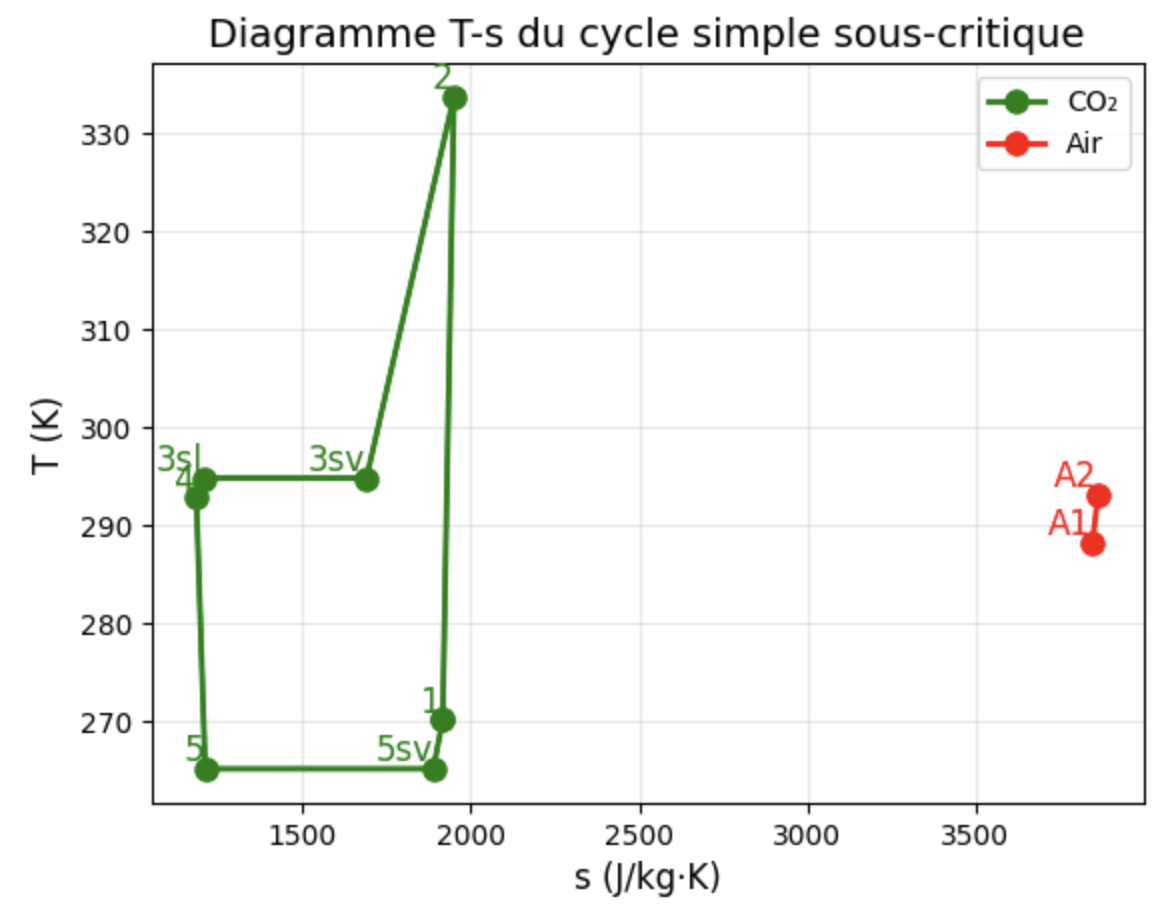

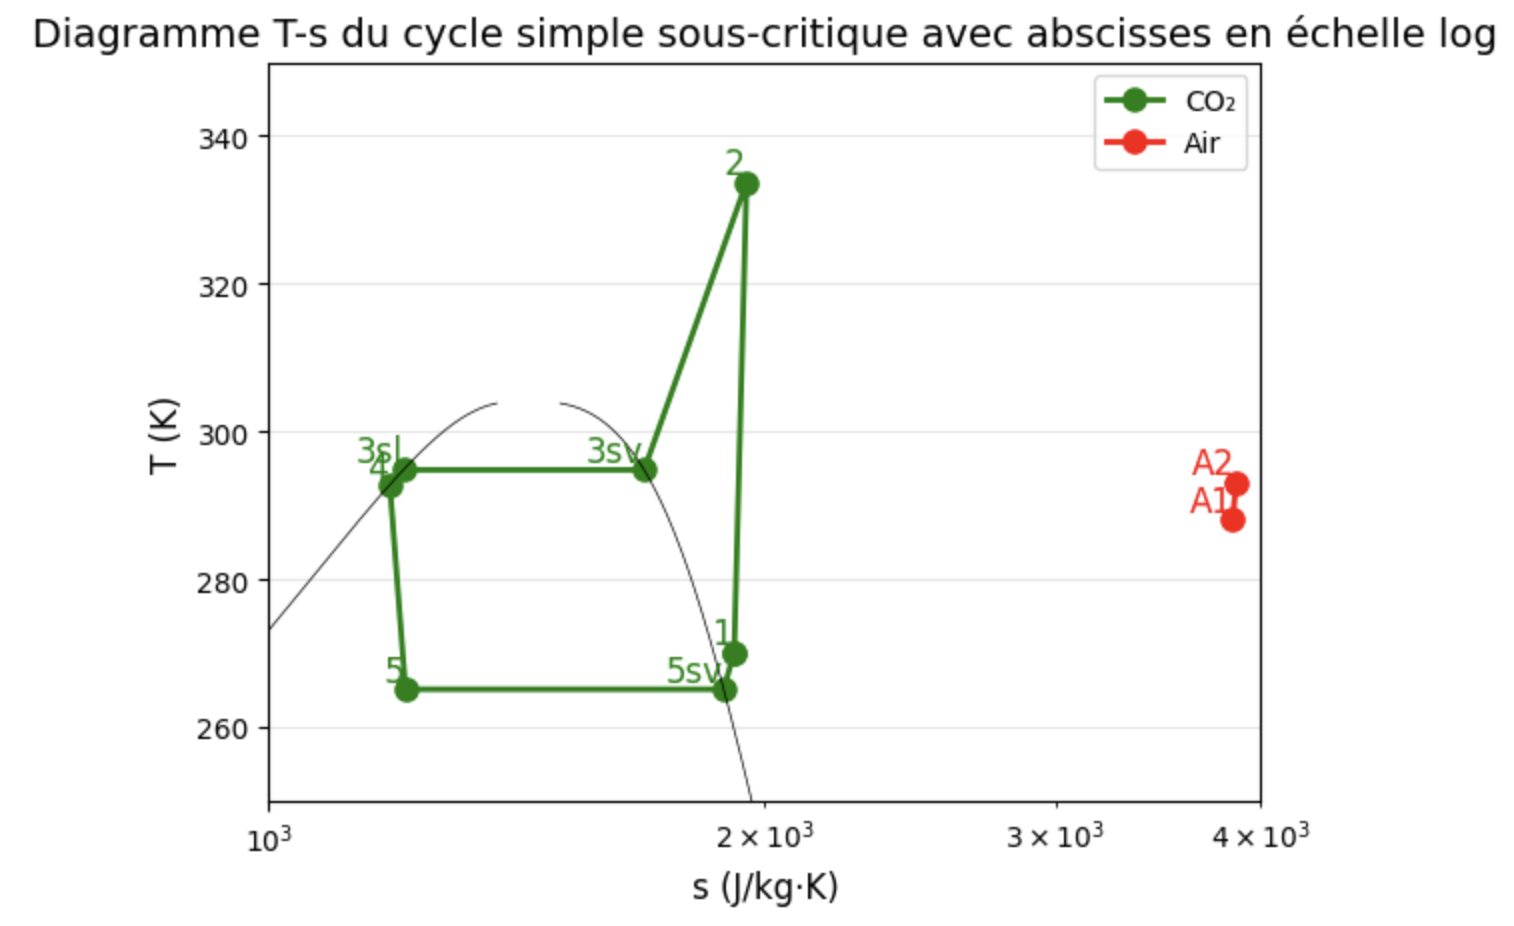

On trace le second graphique pour pouvoir faire apparaître la courbe de saturation.

### Q2.1 : Proposez une hypothèse pour définir la température de sortie du refroidisseur. Analysez l'effet de la pression de refoulement ($𝑃_3$) sur le COP. Commencez l’analyse avec une pression de 120 bar. Tracez le diagramme T-s pour le cas de pression optimale en prenant soin de bien tracer le profil de refroidissement du CO2.

Pour définir la température de sortie du refroidisseur, il faut que $T_{cond} > T_{amb} + 5K = 35K$ étant donné qu'on a toujours un pincement de $5K$ si on est dans un cas similaire au précédent. Or à cette température, on a un changement d'état par passage dans l'état supercritique. On émet alors l'hypothèse que l'on passe par la zone supercritique lors du changement d'état (cf schéma ci-dessous). Le pincement se produit alors au point 3 en sortie du refroidisseur.

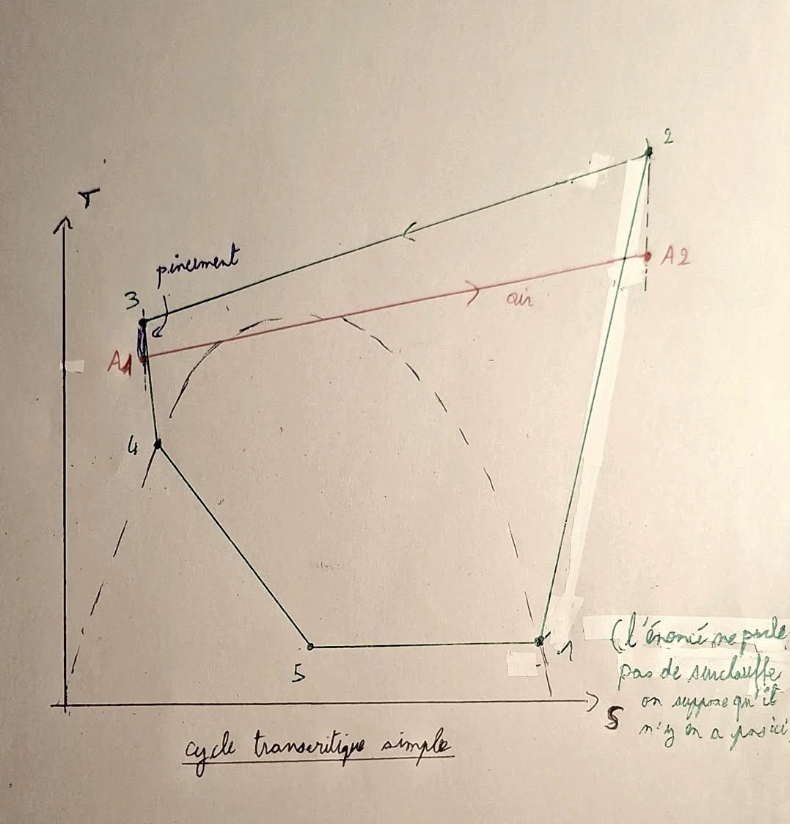

On peut calculer le COP en fonction de $P_3$ en faisant des raisonnements analogues à ceux de la question précdente. Pour $P_3 = 120$ $bar$, on obtient $\eta = 1,17$.

Pour trouver la valeur de $P_3$ qui maximise $\eta$, on va utiliser une méthode itérative détaille dans la fonction maximiseur_COP. On trouve alors : $P_{3,max} = 28.0$ $bar$.

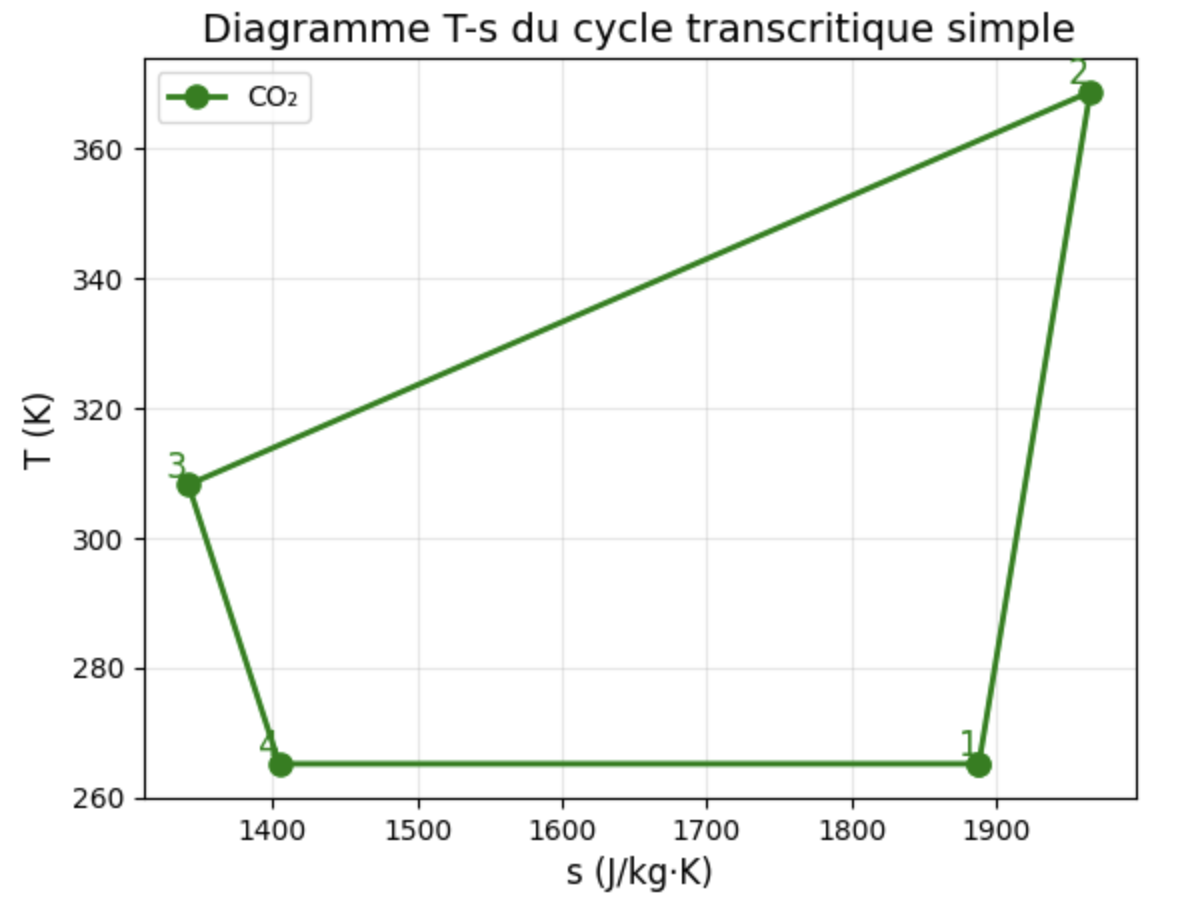

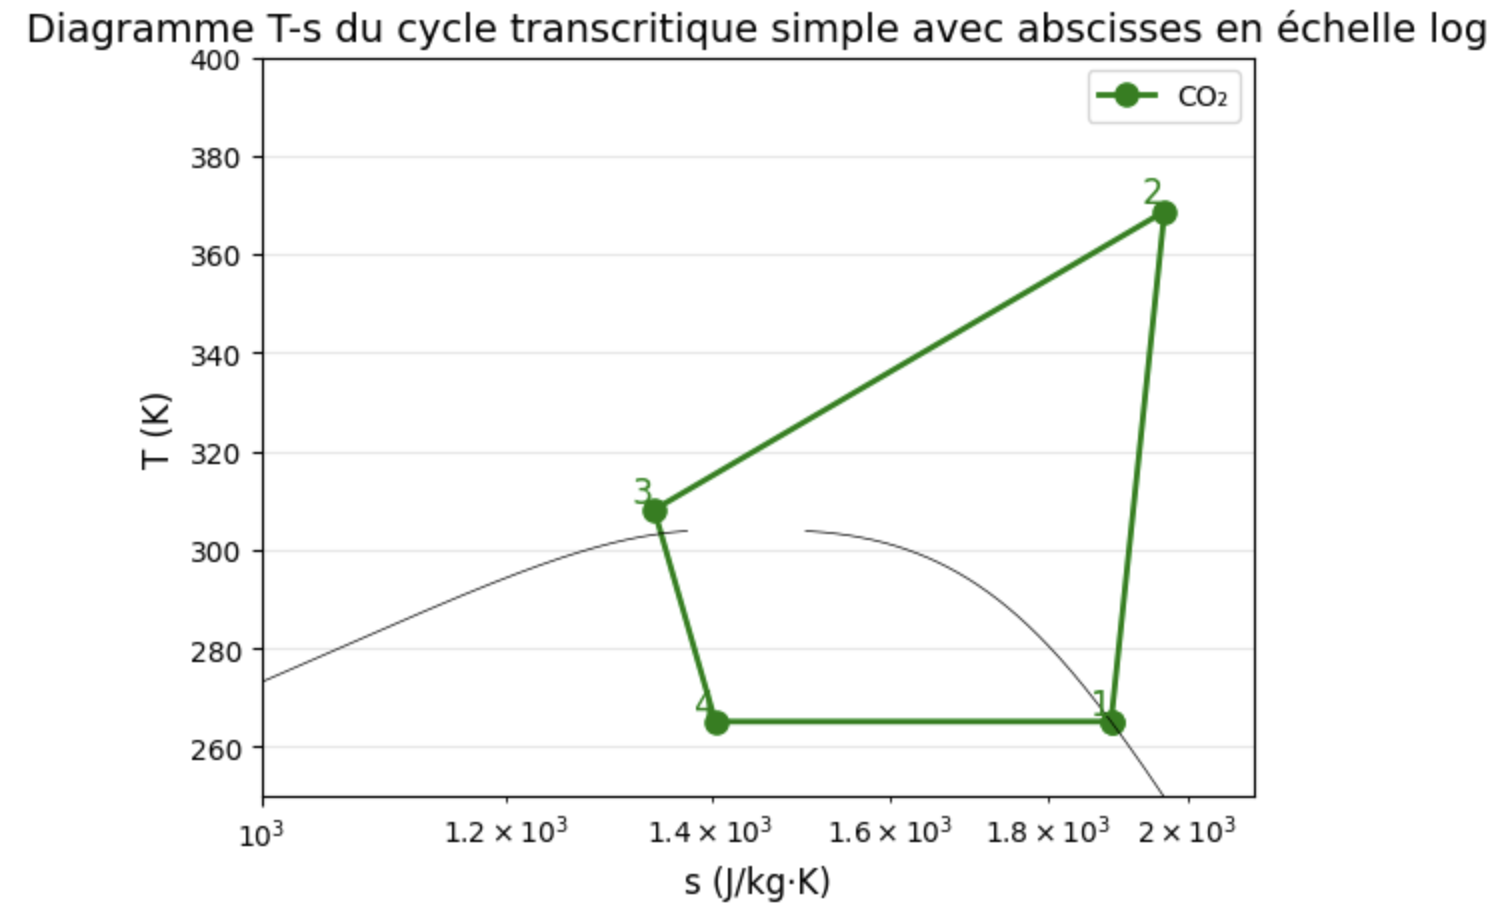

Ici on n'a pas de point sur la courbe de rosée en raison du manque d'informations. On suppose pour le tracé que ce point n'existe pas et que l'on passe directement du point 3 au point 4 tels que représentés ci-dessus.

### Q2.2 : Justifiez pourquoi il existe une pression optimale dans ce régime, contrairement au régime sous-critique.

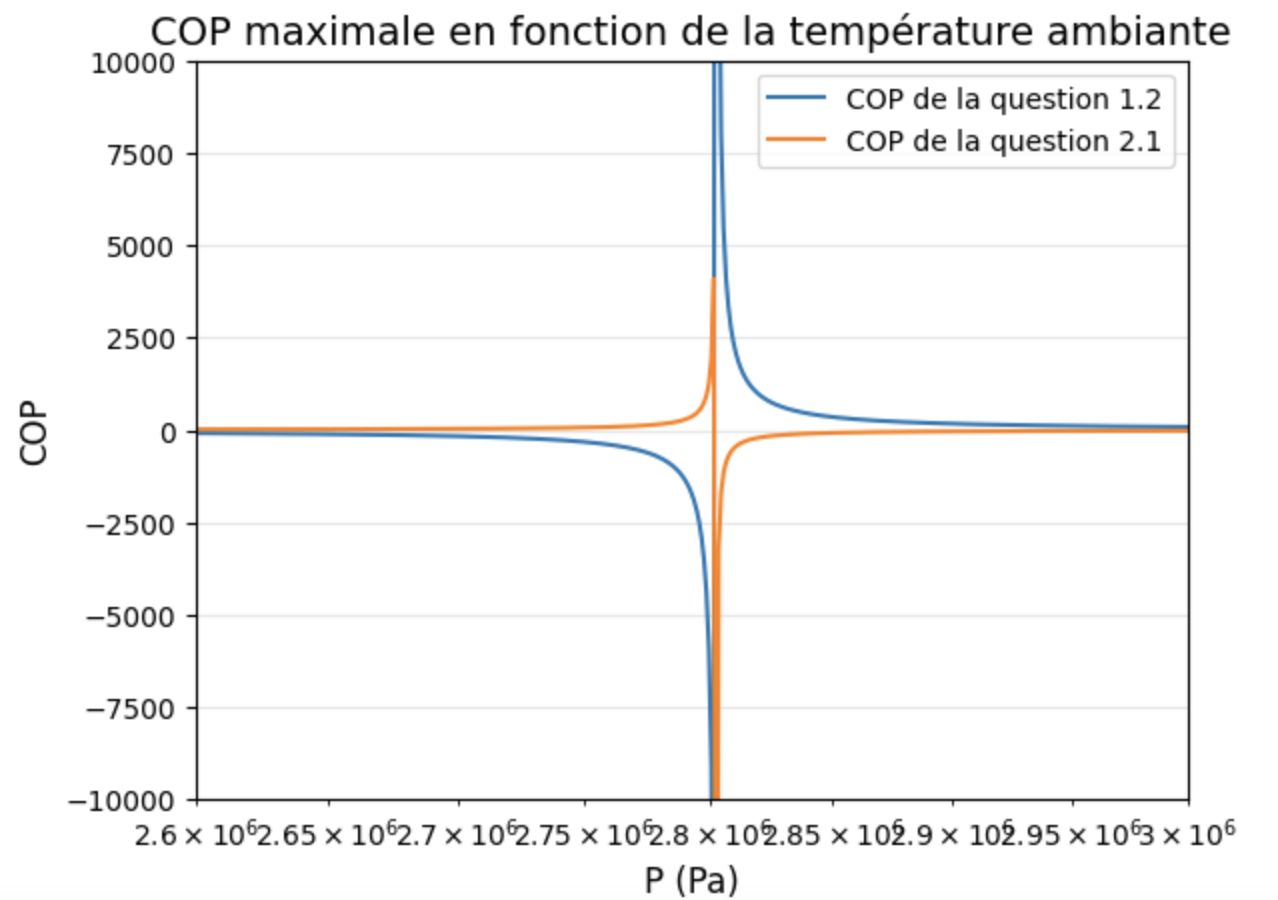

En traçant le COP maximal en fonction de la pression pour les deux régimes étudiés, on constate que pour le régime sous-critique il n'y a pas de maximum tandis qu'il en existe un pour le régime transcritique.

Cette question paraît étonnante étant donné qu'on a montré à la question 1.1 que dans le cas sous-critique, il existe une unique pression $P_3$ solution du problème.

### Q3.1 : Réalisez une étude paramétrique pour $T_{amb}$ variant de 10°C à 40°C par pas de 10°C. Pour chaque point, déterminez la pression adéquate. Tracez l'évolution du COP maximal en fonction de $T_{amb}$.

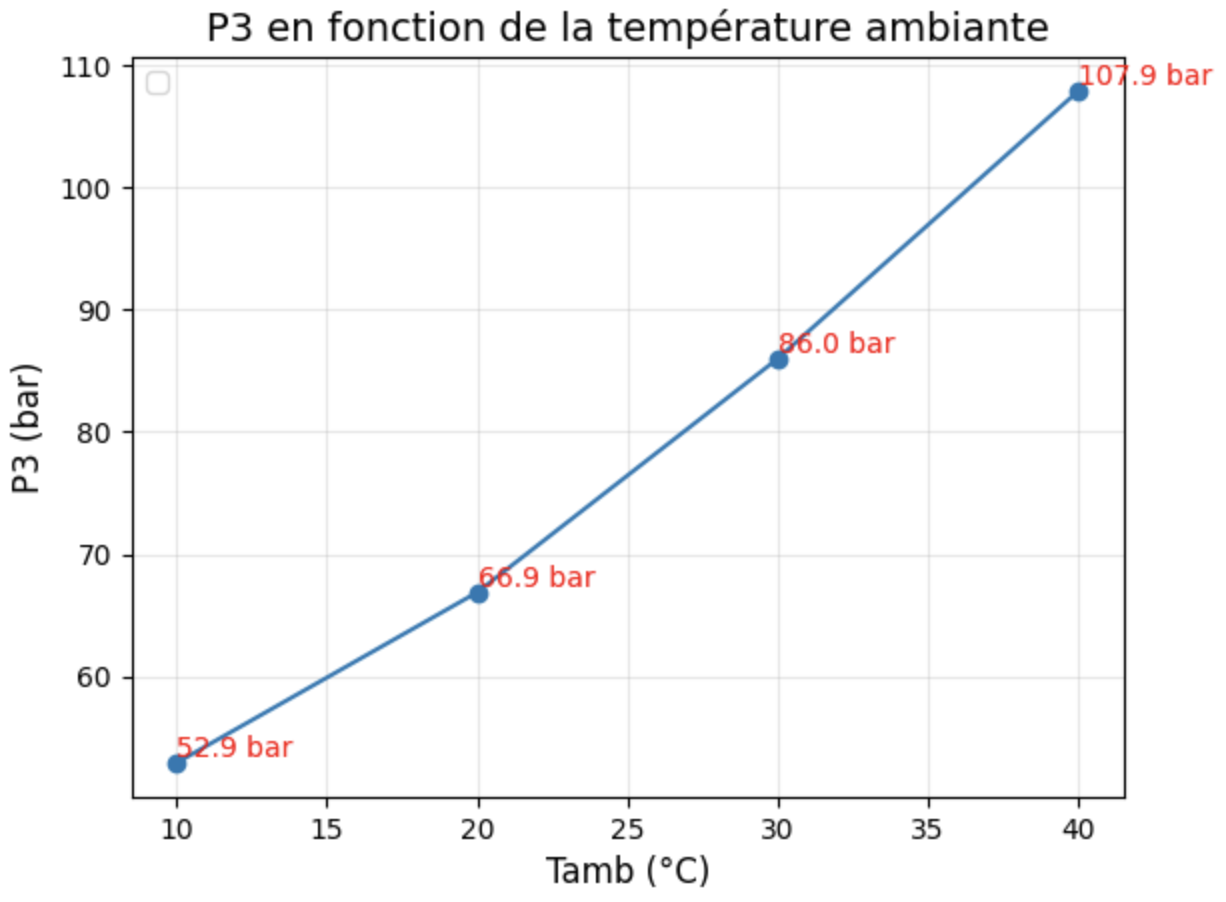

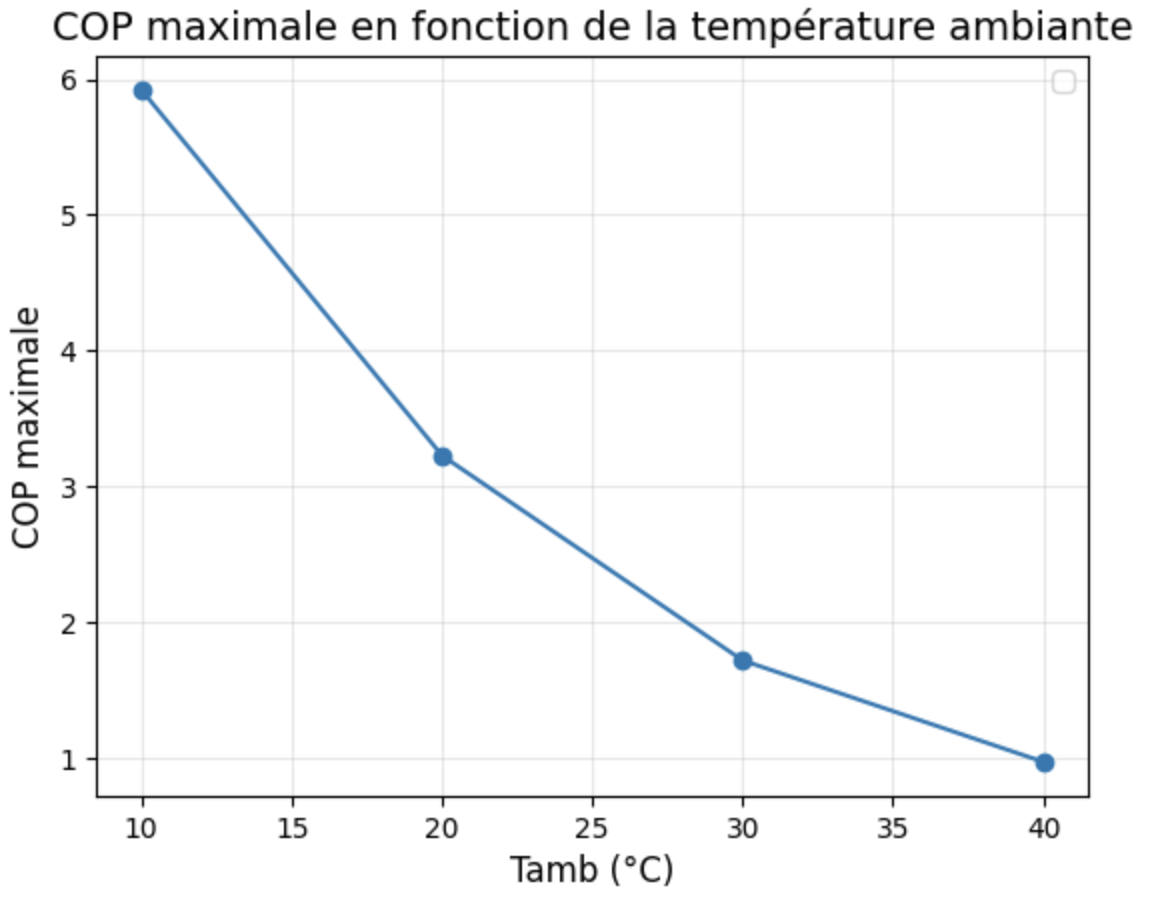

On trace les deux graphiques ci-dessus. Pour le cas sous-critique, on ne peut pas vraiment parler de "COP maximal" puisqu'il s'agit de l'unique COP, déterminée grâce aux données du problème.

### Q4.1 : Intégrez le système DMSS au propane dans votre modèle. Proposez une hypothèse pour le pincement entre le $CO_2$ et le propane. Proposer une expression pour le COP global de l'installation. Analysez l'effet du degré de sous-refroidissement produit par le DMSS ($SC_{DMSS}$) sur le COP à $T_{amb}$ = 30°𝐶.

Pour simplifier, on peut supposer que le pincement entre le $CO_2$ et le propane a lieu en sortie du DMSS (sortie du côté du $CO_2$).

Pour calculer le COP, on raisonne avec CoolProp à partir des hypothèse de l'énconcé. On propose une expression pour le régime sous-critique et une autre pour le régime transcritique et on donne ci-dessous la forme supposée du cylce en régime transcritique.

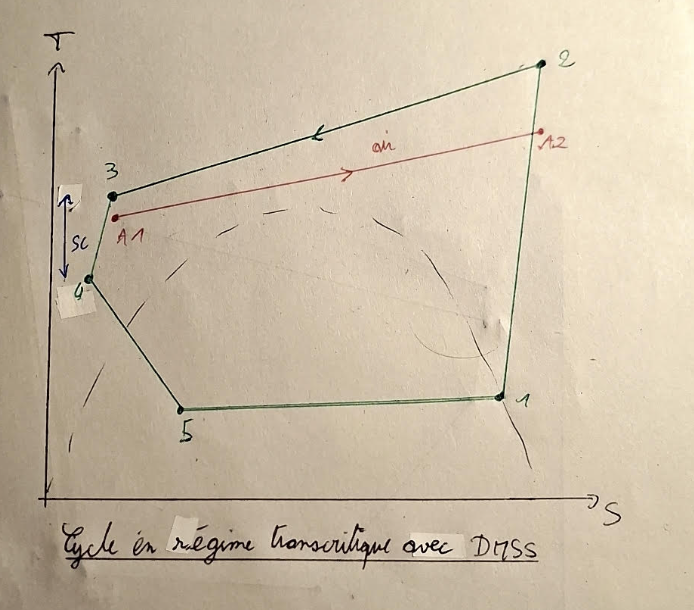

On constate qu'avec le DMSS on a un COP plus élevé, ce qui justifie son utilisation. Pour $T_{amb} = 30°C$, $P_3 = 120$ $bar$ et $SC = 8K$, on a un COP de 1,92 contre 1,17 sans le DMSS. Comme on pouvait s'y attendre, plus SC est élevé, plus le COP est élevé.

Le cycle étant ralongé, il faut fournir un débit de $CO_2$ plus élevé.

### Q4.2 : Pour un degré de sous-refroidissement donné, analysez l'influence de la pression de refoulement du cycle principal sur le COP.

On fixe $SC = 5K$ et on trace le COP en fonction de la pression de refoulement à $T_{amb} =20°C$ (en régime sous-critique) $T_{amb} = 30°C$ (en régime transcritique).

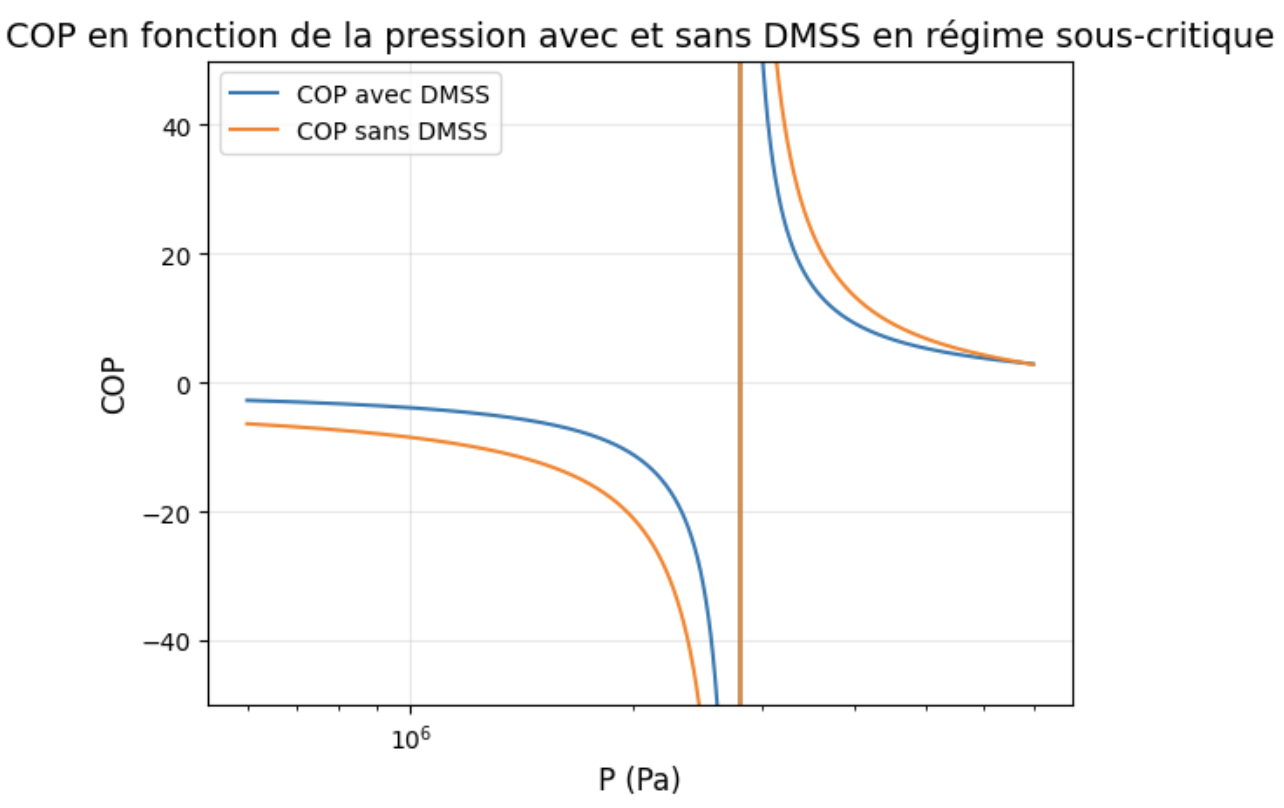

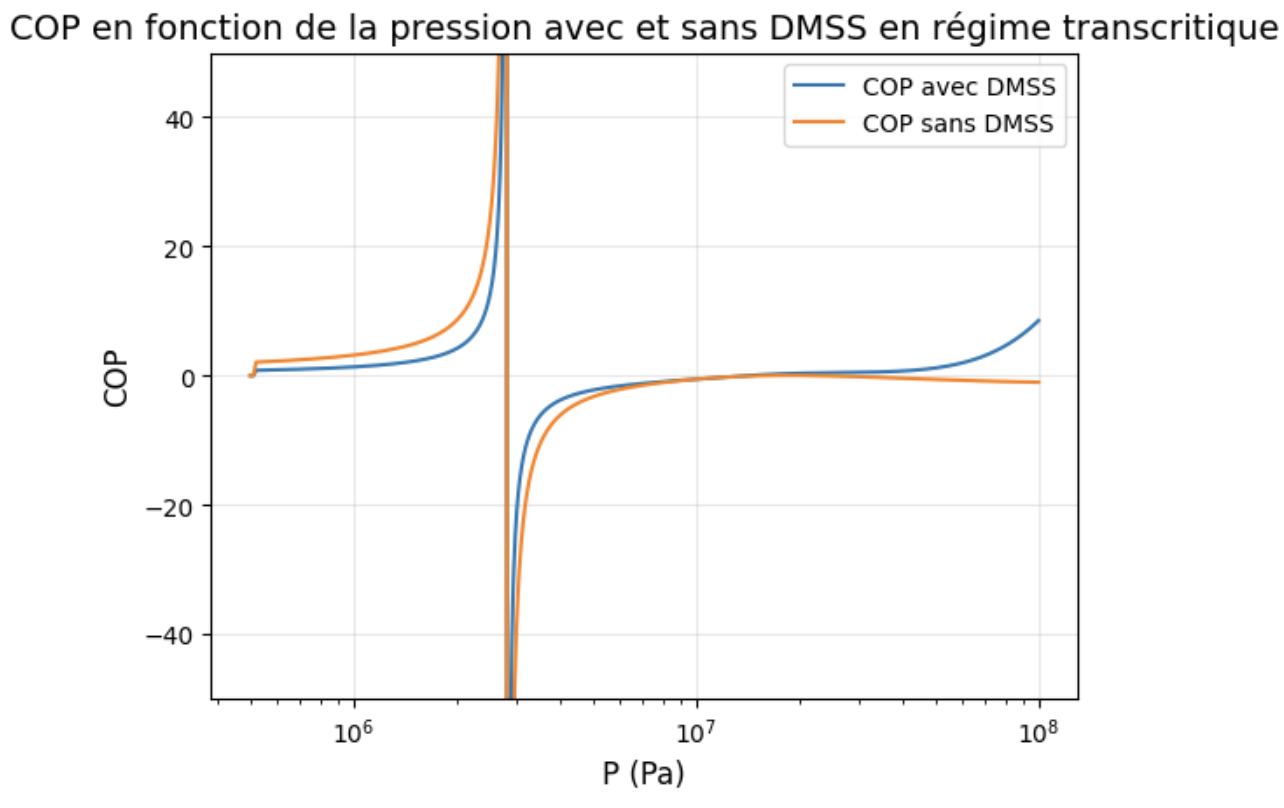

On remarque que dans un cas comme dans l'autre, le COP sans DMSS peut être supérieur au COP avec DMSS.

### Q4.3 : Recherche d'optimum global : Pour chaque température ambiante 10°C à 40°C, déterminez le couple optimal ($P_3$ ; $SC_{DMSS}$) qui maximise le COP global. Un point supplémentaire sera donné pour une méthode de recherche rapide. Il faudra quantifier cette rapidité.

$$
\begin{array}{|l|l|l|} 
\hline  
\text{$T_{amb}$} & \text{$P_{3 optimale}$} & \text{$SC_{optimale}$} \\  
\hline 
\text{$10°C$} & \text{52.9 bar} & \text{15.3K} \\  
\hline 
\text{$20°C$} & \text{66.9 bar} & \text{15.3K} \\  
\hline 
\text{$30°C$} & \text{30.8 bar} & \text{6.12K} \\  
\hline 
\text{$40°C$} & \text{29.6 bar} & \text{3.67K} \\  
\hline
\end{array}
$$

Pour ce qui est de la complexité, elle est en $O(n^2)$ pour le régime transcritique avec $n$ le nombre de valeurs de $SC$ que l'on étudie (ici $n=50$). Le temps d'exécution est d'environ 57 secondes.

Pour le régime sous-critique on à un code en $O(m+n)$ où $m$ correspond au nombre d'itérations utilisées pour calculer $P_3$ et $T_{cond}$. Le temps d'exécution est d'environ 2,3 secondes, donc beaucoup plus court que ce qu'on a dans le cas transcritique. Cela est dû au fait que $P_3$ est directement déterminée à partir de la température ambiante dans le régime sous-critique et ne dépend pas de $SC$.

### Q5 : Comparez les gains obtenus avec le DMSS par rapport au cycle simple. Commentez l'évolution de la pression optimale de fonctionnement avec et sans sous-refroidissement mécanique.

Dans le cas du régime transcritique, le COP optimal est obtenu pour $SC=0$, le DMSS ne présente donc pas d'intérêt pour le cycle selon notre étude.

Pour $T_{amb}=10°C$ ou $20°C$, on donne le tableau suivant :

$$
\begin{array}{|l|l|l|} 
\hline  
\text{$T_{amb}$} & \text{$q_{f, optimale}$ sans DMSS} & \text{$q_{f, optimale}$ sans DMSS} \\  
\hline 
\text{$10°C$} & \text{203 kJ} & \text{302 kJ} \\  
\hline 
\text{$20°C$} & \text{169 kJ} & \text{268 kJ} \\  
\hline 
\end{array}
$$

On constate que la méthode utilisant le DMSS permet d'absorber une quantité d'énergie beaucoup plus importante dans le meuble réfrigéré.

Pour ce qui est de la pression optimale, on obtient assez logiquement quasiment le même pression optimale dans le cas transcritique, la légère différence peut être lié à un manque de précision de la fonction find_optimal_couple_transcritique.

Pour $T_{amb}=10°C$ ou $20°C$, on donne là encore le tableau suivant :

$$
\begin{array}{|l|l|l|} 
\hline  
\text{$T_{amb}$} & \text{$q_{f, optimale}$ sans DMSS} & \text{$q_{f, optimale}$ sans DMSS} \\  
\hline 
\text{$10°C$} & \text{52.9 bar} & \text{302 kJ} \\  
\hline 
\text{$20°C$} & \text{66.9 bar} & \text{268 kJ} \\  
\hline 
\end{array}
$$

Pour ce qui est de la pression optimale, elle est la même dans le cas transcritique avec ou sans DMSS car $SC_{optimal} = 0K$. Quant au cas sous-critique, comme mentionné précédemment, la pression au point 3 est fixé est déterminé à partir de $T_{amb}$ et ne peut varier selon la valeur de $SC$, donc les pressions optimales avec ou sans DMSS sont les mêmes là encore.